### ML: Is the customer going to buy the product that he is looking at or not?
### The whole dataset is big and it is available [ here :](https://www.kaggle.com/datasets/otto/recsys-dataset)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

In [3]:
df_original = pd.read_csv('../data/events_10000_sessions.csv')
df_original

,aid,ts,type,session,datetime,date,hour,weekday
0,1517085,1659304800025,clicks,0,2022-07-31 22:00:00.025,2022-07-31,22,Sunday
1,1563459,1659304904511,clicks,0,2022-07-31 22:01:44.511,2022-07-31,22,Sunday
2,1309446,1659367439426,clicks,0,2022-08-01 15:23:59.426,2022-08-01,15,Monday
3,16246,1659367719997,clicks,0,2022-08-01 15:28:39.997,2022-08-01,15,Monday
4,1781822,1659367871344,clicks,0,2022-08-01 15:31:11.344,2022-08-01,15,Monday
...,...,...,...,...,...,...,...,...
628742,1121381,1661617374727,carts,9999,2022-08-27 16:22:54.727,2022-08-27,16,Saturday
628743,1021005,1661617430111,clicks,9999,2022-08-27 16:23:50.111,2022-08-27,16,Saturday
628744,554476,1661617485935,clicks,9999,2022-08-27 16:24:45.935,2022-08-27,16,Saturday
628745,1021005,1661617498509,clicks,9999,2022-08-27 16:24:58.509,2022-08-27,16,Saturday


In [37]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 628747 entries, 0 to 628746
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   aid       628747 non-null  int64
 1   ts        628747 non-null  int64
 2   type      628747 non-null  str  
 3   session   628747 non-null  int64
 4   datetime  628747 non-null  str  
 5   date      628747 non-null  str  
 6   hour      628747 non-null  int64
 7   weekday   628747 non-null  str  
dtypes: int64(4), str(4)
memory usage: 38.4 MB


#### No missing values 
#### 4 columns integers (aid - ts - session - hour)
#### 4 columns strings (type - datetime - date weekday)

In [38]:
df_original.head()

,aid,ts,type,session,datetime,date,hour,weekday
0,1517085,1659304800025,clicks,0,2022-07-31 22:00:00.025,2022-07-31,22,Sunday
1,1563459,1659304904511,clicks,0,2022-07-31 22:01:44.511,2022-07-31,22,Sunday
2,1309446,1659367439426,clicks,0,2022-08-01 15:23:59.426,2022-08-01,15,Monday
3,16246,1659367719997,clicks,0,2022-08-01 15:28:39.997,2022-08-01,15,Monday
4,1781822,1659367871344,clicks,0,2022-08-01 15:31:11.344,2022-08-01,15,Monday


### Count events by type:
* counts clicks, carts, and orders and visualizes their frequencies in a bar chart. This reveals how common each customer action is in the dataset.

type
clicks    571560
carts      45202
orders     11985
Name: count, dtype: int64


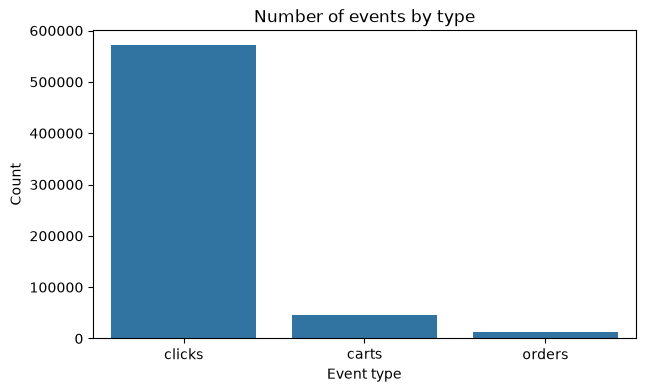

In [39]:
event_counts = df_original["type"].value_counts()

print(event_counts)

plt.figure(figsize=(7, 4))
sns.barplot(
    x=event_counts.index,
    y=event_counts.values
)
plt.title("Number of events by type")
plt.xlabel("Event type")
plt.ylabel("Count")
plt.show()

### Analyze events per session

* The descriptive statistics and histogram show how many events each session contains, including the typical session size and the spread of session activity.

count    10000.000000
mean        62.874700
std         85.291679
min          2.000000
25%          8.000000
50%         26.000000
75%         81.000000
max        495.000000
dtype: float64


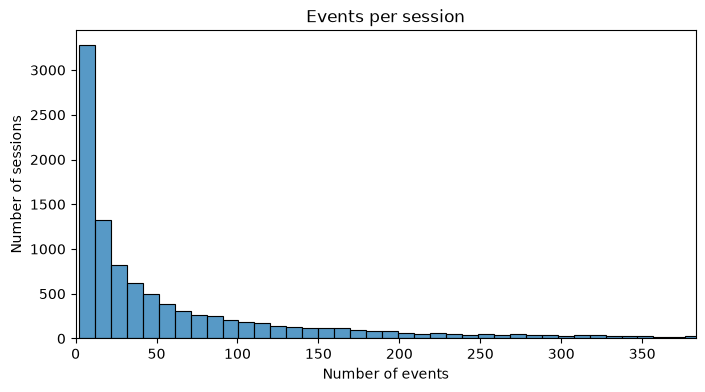

In [40]:
events_per_session = df_original.groupby("session").size()

print(events_per_session.describe())

plt.figure(figsize=(8, 4))
sns.histplot(events_per_session, bins=50)
plt.title("Events per session")
plt.xlabel("Number of events")
plt.ylabel("Number of sessions")
plt.xlim(0, events_per_session.quantile(0.99))
plt.show()

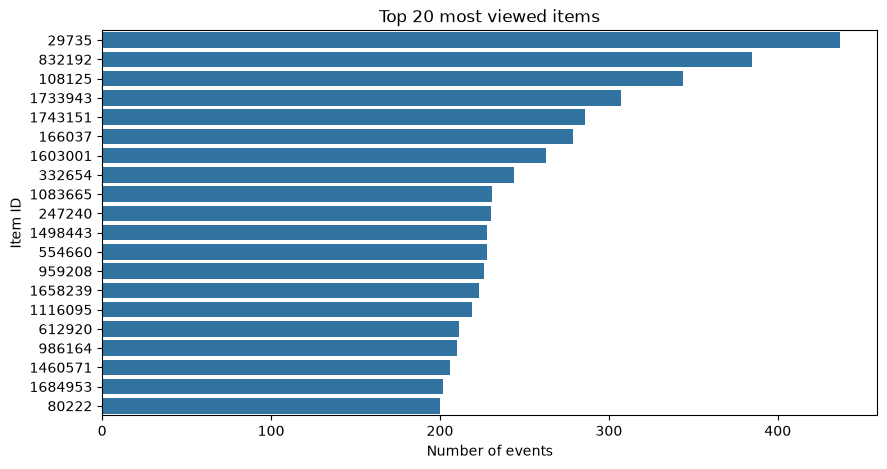

In [41]:
top_items = df_original["aid"].value_counts().head(20)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_items.values,
    y=top_items.index.astype(str),
    orient="h"
)
plt.title("Top 20 most viewed items")
plt.xlabel("Number of events")
plt.ylabel("Item ID")
plt.show()

### Compare item event types

* A crosstab summarizes clicks, carts, and orders for each item, and the twenty items with the highest total event count are displayed.

In [42]:
item_type_counts = pd.crosstab(
    df_original["aid"],
    df_original["type"]
)

item_type_counts["total"] = item_type_counts.sum(axis=1)

item_type_counts.sort_values(
    "total",
    ascending=False
).head(20)

type,carts,clicks,orders,total
aid,,,,
29735,43,388,6,437
832192,48,331,6,385
108125,6,338,0,344
1733943,28,272,7,307
1743151,30,253,3,286
166037,48,216,15,279
1603001,14,245,4,263
332654,28,206,10,244
1083665,20,203,8,231


### Create time-based features

* The timestamp is converted to a datetime, date, hour, and weekday. A preview confirms the new time-related columns.

In [43]:
df_original["datetime"] = pd.to_datetime(
    df_original["ts"],
    unit="ms"
)

df_original["date"] = df_original["datetime"].dt.date
df_original["hour"] = df_original["datetime"].dt.hour
df_original["weekday"] = df_original["datetime"].dt.day_name()

df_original[["datetime", "date", "hour", "weekday"]].head()

,datetime,date,hour,weekday
0,2022-07-31 22:00:00.025,2022-07-31,22,Sunday
1,2022-07-31 22:01:44.511,2022-07-31,22,Sunday
2,2022-08-01 15:23:59.426,2022-08-01,15,Monday
3,2022-08-01 15:28:39.997,2022-08-01,15,Monday
4,2022-08-01 15:31:11.344,2022-08-01,15,Monday


### Analyze activity by hour

* Events are counted for each hour of the day and plotted, showing when customer activity is highest.

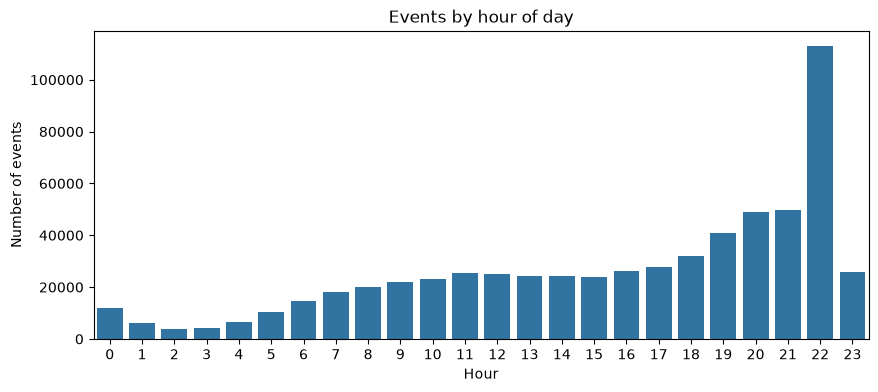

In [44]:
hourly_events = df_original["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(
    x=hourly_events.index,
    y=hourly_events.values
)
plt.title("Events by hour of day")
plt.xlabel("Hour")
plt.ylabel("Number of events")
plt.show()

### ML
# The hypothesis: 
---
---
## **Customer session behavior, such as the number of clicks, carts, total events, and unique items viewed, can be used to predict whether the customer will place an order during that session or not**
---
---
### Define the session target

* **Each session receives target `1` when it contains at least one order and target `0` otherwise. This is the classification label for the ML models.**
---

In [45]:
session_target = (
    df_original.groupby("session")["type"]
    .apply(lambda values: ("orders" in values.values))
    .astype(int)
)

### Aggregate session-level features

* Event-level records are converted into one row per session with counts of clicks, carts, orders, total events, and unique items.

In [46]:
# Aggregate browsing events (excluding orders to prevent target leakage)
df_browsing = df_original[df_original["type"] != "orders"]
session_features = df_browsing.groupby("session").agg(
    num_clicks = ("type", lambda x: (x == "clicks").sum()),
    num_carts = ("type", lambda x: (x == "carts").sum()),
    num_events = ("type", "count"),
    num_unique_items = ("aid", "nunique"),
)
session_features.head()

,num_clicks,num_carts,num_events,num_unique_items
session,,,,
0,255,17,276,183
1,24,8,32,22
2,32,1,33,29
3,200,21,226,140
4,15,3,19,12


### Add the target to the feature table

* The session-level target is added to `session_features`, allowing the target distribution to be inspected before modeling.

In [47]:
session_features["target"] = session_target
session_features["target"]

session
0       1
1       0
2       0
3       1
4       1
       ..
9995    0
9996    0
9997    0
9998    1
9999    0
Name: target, Length: 10000, dtype: int64

### Separate features and target

* The leakage-prone `num_orders` column and the target are removed from `x`, while `y` contains the binary order label.

In [48]:
x = session_features.drop(columns=["target"])
y = session_features["target"]

### Split the data into train, validation, and test sets

* The session data is divided into training, validation, and test subsets. The validation set supports model selection, while the test set remains unseen until final evaluation.

In [49]:
x_train_val , x_test, y_train_val, y_test = train_test_split(x,y, test_size=0.2, random_state=42 )
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.15, random_state=40)

### Scale the model inputs

* Standardization is fitted on the training features and applied to the validation and test features, preparing comparable inputs.

In [50]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

### Define the classification models

* Three balanced classifiers are configured: Logistic Regression, Support Vector Classifier, and Random Forest.

In [51]:
# Model 1: Logistic Regression
log_reg_base = LogisticRegression(class_weight="balanced", random_state=42)
param_grid_logreg = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000, 2000]
}

grid_log = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
# Model 2: Support Vector Classifier
svc_base = SVC(class_weight="balanced", probability=True, random_state=42)

param_grid_svc = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
}

grid_svc = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid_svc,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)


# Model 3: Random Forest
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)


NameError: name 'log_reg_base' is not defined

### Train the classifiers

* Logistic Regression, SVC, and Random Forest are fitted on the training data, then generate validation predictions and purchase probabilities.

In [ ]:
# Train Logistic Regression
grid_log.fit(x_train_scaled, y_train)
best_log_reg = grid_log.best_estimator_

log_val_pred = best_log_reg.predict(x_val_scaled)
log_val_prob = best_log_reg.predict_proba(x_val_scaled)[:, 1]

# Train Support Vector Classifier on scaled features

grid_svc.fit(x_train_scaled, y_train)
best_svc_base = grid_svc.best_estimator_

# CalibratedClassifierCV
best_svc = CalibratedClassifierCV(
    estimator=best_svc_base,
    method="sigmoid",
    cv=5,
)
best_svc.fit(x_train_scaled, y_train)

svc_val_pred = best_svc.predict(x_val_scaled)
svc_val_prob = best_svc.predict_proba(x_val_scaled)[:, 1]

# Train Random Forest

grid_rf.fit(x_train, y_train)
best_rf = grid_rf.best_estimator_

rf_val_pred = best_rf.predict(x_val)
rf_val_prob = best_rf.predict_proba(x_val)[:, 1]

### Compare validation performance

* Accuracy, precision, recall, F1-score, ROC-AUC, and average precision are calculated for all three models. The rows are sorted by validation F1-score so the strongest balanced classifier appears first.

In [ ]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1_score": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
    }


results = pd.DataFrame(
    [
        evaluate_model("Logistic Regression", y_val, log_val_pred, log_val_prob),
        evaluate_model("SVC", y_val, svc_val_pred, svc_val_prob),
        evaluate_model("Random Forest", y_val, rf_val_pred, rf_val_prob),
    ]
).sort_values("f1_score", ascending=False)

print(results)

,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
2,Random Forest,0.858333,0.706150,0.883191,0.784810,0.937725,0.810957
0,Logistic Regression,0.852500,0.765244,0.715100,0.739323,0.924782,0.785863
1,SVC,0.824167,0.701149,0.695157,0.698140,0.909906,0.779411


### train_val
* Retrain the chosen model on both train and validation data before it can see the test data.

In [ ]:
best_model_name = results.iloc[0]["model"]
print(f"Best model based on validation F1-score: {best_model_name}")

# Refit the selected model on the combined training and validation data.
if best_model_name == "Logistic Regression":
    final_scaler = StandardScaler()
    x_train_val_final = final_scaler.fit_transform(x_train_val)
    x_test_final = final_scaler.transform(x_test)
    best_model = best_log_reg

elif best_model_name == "SVC":
    final_scaler = StandardScaler()
    x_train_val_final = final_scaler.fit_transform(x_train_val)
    x_test_final = final_scaler.transform(x_test)
    best_model = best_svc

else:  # Random Forest
    x_train_val_final = x_train_val
    x_test_final = x_test
    best_model = best_rf

best_model.fit(x_train_val_final, y_train_val)
best_test_pred = best_model.predict(x_test_final)
best_test_prob = best_model.predict_proba(x_test_final)[:, 1]

print("\nTest-set classification report:")
print(
    classification_report(
        y_test,
        best_test_pred,
        target_names=["No order", "Order"],
        zero_division=0,
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_test, best_test_pred))

print(f"Accuracy:          {accuracy_score(y_test, best_test_pred):.4f}")
print(f"Precision:         {precision_score(y_test, best_test_pred, zero_division=0):.4f}")
print(f"Recall:            {recall_score(y_test, best_test_pred, zero_division=0):.4f}")
print(f"F1-score:          {f1_score(y_test, best_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, best_test_prob):.4f}")
print(f"Average precision: {average_precision_score(y_test, best_test_prob):.4f}")

Best model based on validation F1-score: Random Forest

Test-set classification report:
              precision    recall  f1-score   support

    No order       0.95      0.86      0.90      1414
       Order       0.73      0.88      0.80       586

    accuracy                           0.87      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.88      0.87      0.87      2000

Confusion matrix:
[[1221  193]
 [  71  515]]
Accuracy:          0.8680
Precision:         0.7274
Recall:            0.8788
F1-score:          0.7960
ROC-AUC:           0.9393
Average precision: 0.8412


### Visualize the confusion matrix

* The confusion matrix displays correct and incorrect predictions for the selected model, separated into the `No order` and `Order` classes.

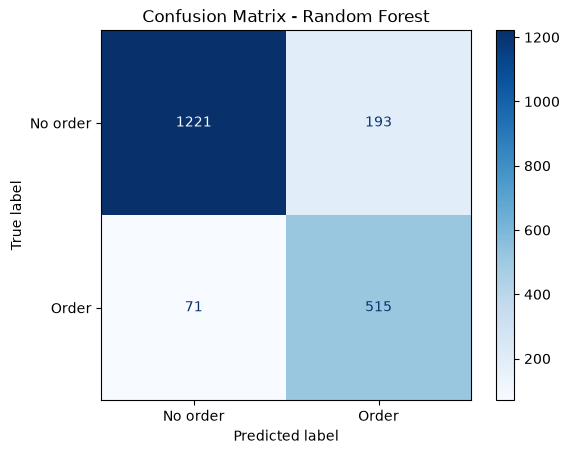

In [ ]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_test_pred,
    display_labels=["No order", "Order"],
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()



### Inspect individual test predictions

* The first twenty test sessions are shown with their actual label, predicted label, purchase probability, and whether the prediction was correct.

In [ ]:
prediction_details = x_test.copy()
prediction_details["actual_order"] = y_test
prediction_details["predicted_order"] = best_test_pred
prediction_details["order_probability"] = best_test_prob

prediction_details["prediction_correct"] = (
    prediction_details["actual_order"]
    == prediction_details["predicted_order"]
)

prediction_details.head(20)

,num_clicks,num_carts,num_events,num_unique_items,actual_order,predicted_order,order_probability,prediction_correct
session,,,,,,,,
6252,13,0,13,7,0,0,0.006181,True
4684,15,11,27,6,1,1,0.558747,True
1731,51,13,80,47,1,1,0.964476,True
4742,39,0,39,36,0,0,0.001667,True
4521,8,1,9,7,0,0,0.123097,True
6340,38,5,43,28,0,1,0.687950,False
576,11,0,11,10,0,0,0.004234,True
5202,11,1,12,8,0,0,0.059058,True
6363,283,11,295,103,1,1,0.955278,True


### Examine feature importance

* When Random Forest is selected, the code displays and plots the relative importance of each session feature. This helps explain which behaviors contribute most to the prediction.

Feature importance:


,importance
num_carts,0.446026
num_events,0.263932
num_clicks,0.189349
num_unique_items,0.100693


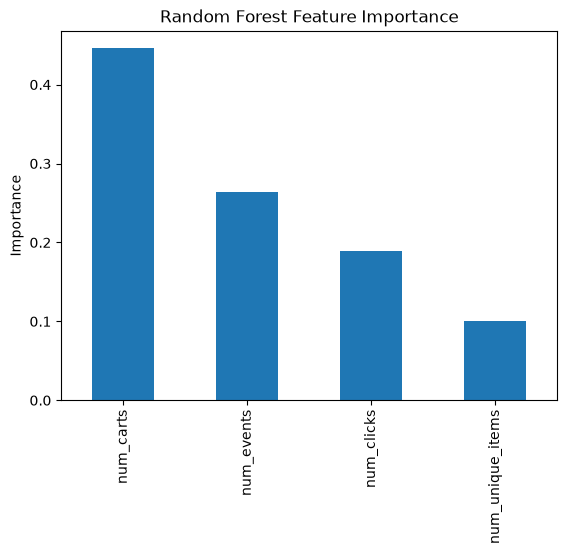

In [ ]:
if best_model_name == "Random Forest":
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=x.columns
    ).sort_values(ascending=False)

    print("Feature importance:")
    display(feature_importance.to_frame("importance"))

    feature_importance.plot(kind="bar", title="Random Forest Feature Importance")
    plt.ylabel("Importance")
    plt.show()

### Summary and business meaning

- The data contains customer sessions and events such as clicks, carts, and orders. Each session was aggregated into numerical features. The target indicates whether the customer placed an order.

- The data was divided into training, validation, and test sets. Logistic Regression, calibrated Support Vector Classifier (SVM), and Random Forest were trained and compared using accuracy, precision, recall, F1-score, and ROC-AUC. The SVM was selected for the final evaluation and evaluated on unseen test data.

- `num_orders` was removed from the features because it directly reveals the target and would cause data leakage. The target is 1 when the session contains an order, otherwise 0.

- In real business life, the model predicts whether a customer is likely to buy during a session. The company could use this prediction to offer personalised discounts, recommendations, reminders, or customer support.

- Precision shows how often predicted buyers actually buy. Recall shows how many real buyers the model finds. F1-score balances both measures. The most suitable metric depends on the business cost of missed customers and unnecessary marketing actions.

- A business could use this prediction to:

* Show discounts to visitors with a high purchase probability.
* Send reminders to visitors who may need additional encouragement.
* Prioritize customer-service support.
* Personalize product recommendations.
* Measure which session behaviors are connected to purchases.
* Recall is important when missing a potential buyer is expensive. Precision is important when campaigns or discounts are costly. The best model should therefore be selected according to the business objective, not accuracy alone.

### Predict a new session outcome

* The trained best model predicts whether the example session will result in an order and reports the associated purchase probability.

In [ ]:
new_session = pd.DataFrame([{
    "num_clicks": 12,
    "num_carts": 2,
    "num_events": 15,
    "num_unique_items": 8
}])

if best_model_name in ["Logistic Regression", "SVC"]:
    new_input = scaler.transform(new_session)
else:
    new_input = new_session

prediction = best_model.predict(new_input)[0]
probability = best_model.predict_proba(new_input)[0, 1]

print("Predicted order:", "Yes" if prediction == 1 else "No")
print(f"Purchase probability: {probability:.2%}")

Predicted order: No
Purchase probability: 42.85%


### As we have seen Random Forest is the best model.

### On unseen test data, it achieved:

* Accuracy: 86.80% overall correct predictions
* Precision: 72.74% of predicted buyers actually placed an order
* Recall: 87.88% of actual buyers were correctly identified
* F1-score: 79.60%
* ROC-AUC: 93.93%
* So, the simplest answer is: the model predicts new cases correctly about 86% of the time.